In [1]:
import cv2
import numpy as np
import os
from skimage.metrics import structural_similarity as ssim
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML, Markdown


# Valutazione Quantitativa della Stabilizzazione Video

## Obiettivo
L'obiettivo è quello di effettuare una valutazione quantitativa dell'efficacia dei due algoritmi di video stabilization trattati nei precedenti notebook.

## Metriche Utilizzate

### 1. PSNR (Peak Signal-to-Noise Ratio)
- **Formula**: PSNR = 20 × log₁₀(255 / √MSE)
- **Interpretazione**: Misura la similarità numerica frame-by-frame rispetto al video groundtruth
- **Range**: 0 - 100 dB (più alto = migliore)
- **Significato**: Un valore più alto indica che il frame stabilizzato è più simile al groundtruth, quindi la stabilizzazione ha introdotto meno distorsioni

### 2. SSIM (Structural Similarity Index)
- **Formula**: Basata su luminanza, contrasto e struttura dell'immagine
- **Interpretazione**: Misura la similarità strutturale percepita dall'occhio umano
- **Range**: -1 a 1 (più alto = migliore)
- **Significato**: Più correlato alla percezione visiva rispetto a PSNR. Un valore più alto significa che il video stabilizzato mantiene meglio la struttura del groundtruth

### 3. Stability Score (Varianza Inter-frame)
- **Formula**: Score = (Var(dx) + Var(dy) + Var(da)) / 3
  - dx, dy: traslazioni residue tra frame consecutivi (pixel)
  - da: rotazione residua (radianti)
- **Interpretazione**: Misura il "tremolo" residuo nel video stabilizzato
- **Range**: 0 - ∞ (più basso = migliore)
- **Significato**: Se la stabilizzazione è efficace, il movimento tra frame consecutivi dovrebbe essere minimo. Questo score è indipendente dal groundtruth ed è una misura diretta della qualità di stabilizzazione

## Metodologia

1. Per ogni folder vengono elaborati:
   - Video shaky originale
   - Video stabilizzato con Lucas-Kanade
   - Video stabilizzato con ORB+RANSAC
   - Video Groundtruth

2. Per ogni frame vengono calcolate le metriche rispetto al groundtruth

3. Viene stimata la trasformazione affine tra frame consecutivi per misurare il movimento residuo

In [2]:
data_dir = "data"
folders = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d)) and not d.startswith('.')])
print(f"Cartelle trovate: {folders}")

all_results = {}


Cartelle trovate: ['climbing1', 'climbing2', 'driving1', 'driving2', 'riding1', 'riding2', 'walking1', 'walking2']


## Implementazione delle Metriche

### Calcolo PSNR e SSIM
Le due metriche seguenti valutano quanto il video stabilizzato sia simile al groundtruth:
- **PSNR**: Metrica basata sull'errore quadratico medio (MSE) tra i frame
- **SSIM**: Metrica basata sull'analisi strutturale dell'immagine (più correlata alla percezione umana)

Entrambe vengono calcolate frame-by-frame per ottenere un profilo temporale e poi mediate.

### Calcolo dello Stability Score
Per misurare la stabilità del video, viene stimata la trasformazione affine tra frame consecutivi utilizzando:
1. **Rilevamento ORB features**: Estrae punti feature robusti dalle immagini
2. **Matching ORB**: Fa corrispondere i feature tra frame consecutivi
3. **RANSAC**: Rimuove i match errati e stima la trasformazione affine
4. **Estrazione parametri**: Estrae traslazioni (dx, dy) e rotazione (da)
5. **Calcolo varianza**: Se il video è stabile, la varianza di questi parametri deve essere bassa


In [3]:
def compute_psnr (frame1, frame2) :
    # Più alto più simile al gt
    mse = np.mean((frame1.astype(np.float32) - frame2.astype(np.float32)) ** 2)
    if mse == 0 :
        return 100.0
    return 20 * np.log10(255.0 / np.sqrt(mse))

def compute_ssim (frame1, frame2) :
    # Più alto più simile al gt
    gray1 = cv2.cvtColor(frame1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(frame2, cv2.COLOR_BGR2GRAY)
    score, _ = ssim(gray1, gray2, full=True)
    return score

def compute_interframe_transform (prev_gray, curr_gray) :
    """
    Stima la trasformazione affine tra due frame consecutivi.
    Restituisce dx, dy, da (traslazione e rotazione residua).
    Usata per calcolare lo Stability Score.
    """
    orb = cv2.ORB_create(nfeatures=500)
    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=False)
    kp1, des1 = orb.detectAndCompute (prev_gray, None)
    kp2, des2 = orb.detectAndCompute (curr_gray, None)

    if des1 is None or des2 is None or len(kp1) < 4 or len(kp2) < 4 :
        return 0.0, 0.0, 0.0
    
    matches = bf.knnMatch(des1, des2, k=2)
    good = [m for m, n in matches if m.distance < 0.75 * n.distance]

    if len(good) < 4 :
        return 0.0, 0.0, 0.0
    
    pts1 = np.float32([kp1[m.queryIdx].pt for m in good])
    pts2 = np.float32([kp2[m.trainIdx].pt for m in good])

    m_affine, _ = cv2.estimateAffine2D(pts1, pts2, method=cv2.RANSAC)

    if m_affine is None :
        return 0.0, 0.0, 0.0
    
    dx = m_affine[0,2]
    dy = m_affine[1,2]
    da = np.arctan2(m_affine[1,0], m_affine[0,0])
    return dx, dy, da

## Elaborazione dei Dati

Per ogni cartella viene calcolato:
1. PSNR e SSIM dei frame stabilizzati vs groundtruth
2. Stability Score basato sul movimento inter-frame residuo
3. Confronto tra i due metodi di stabilizzazione

I risultati sono organizzati in:
- **Analisi dettagliata per cartella**: Metriche specifiche di ogni video
- **Riepilogo complessivo**: Tabella riassuntiva di tutti i video
- **Media globale**: Risultati medi su tutti i test
- **Grafici temporali**: Andamento delle metriche nel tempo
- **Istogrammi comparativi**: Confronto visuale tra i metodi


In [4]:
for folder in folders:
    print(f"\n{'='*60}")
    print(f"Analisi: {folder}")
    print(f"{'='*60}")
    
    path = os.path.join(data_dir, folder)
    
    shaky_video = os.path.join(path, "shaky.mp4")
    lk_video = os.path.join(path, "Lucas-Kanade Optical Flow", "comparison_shaky.mp4")
    orb_video = os.path.join(path, "ORB+RANSAC", "comparison_shaky.mp4")
    gt_video = os.path.join(path, "groundtruth.mp4")
    
    if not all(os.path.exists(v) for v in [shaky_video, lk_video, orb_video, gt_video]):
        print(f"SKIP: Video mancanti per {folder}")
        continue
    
    cap_shaky = cv2.VideoCapture(shaky_video)
    cap_lk = cv2.VideoCapture(lk_video)
    cap_orb = cv2.VideoCapture(orb_video)
    cap_gt = cv2.VideoCapture(gt_video)
    
    n_frames = int(cap_shaky.get(cv2.CAP_PROP_FRAME_COUNT))
    
    full_w = int(cap_lk.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap_lk.get(cv2.CAP_PROP_FRAME_HEIGHT))
    w = full_w // 2  # i video hanno dimensione (2*w, h)
    
    metrics = {
        "psnr_lk": [], "psnr_orb": [],
        "ssim_lk": [], "ssim_orb": [],
        "dx_lk": [], "dy_lk": [], "da_lk": [],
        "dx_orb": [], "dy_orb": [], "da_orb": [],
        "dx_shaky": [], "dy_shaky": [], "da_shaky": [],
        "dx_gt": [], "dy_gt": [], "da_gt": []
    }
    
    prev_lk_gray = None
    prev_orb_gray = None
    prev_shaky_gray = None
    prev_gt_gray = None
    
    for frame_idx in range(n_frames - 1):
        success_shaky, frame_shaky = cap_shaky.read()
        success_lk, frame_lk_full = cap_lk.read()
        success_orb, frame_orb_full = cap_orb.read()
        success_gt, frame_gt = cap_gt.read()
        
        if not (success_shaky and success_lk and success_orb and success_gt):
            break
        
        # Estrai frame stabilizzati (metà destra dei video)
        frame_lk_stab = frame_lk_full[:, w:, :]
        frame_orb_stab = frame_orb_full[:, w:, :]
        
        # Ridimensiona groundtruth se necessario
        if frame_gt.shape[:2] != (h, w):
            frame_gt = cv2.resize(frame_gt, (w, h))
        
        metrics["psnr_lk"].append(compute_psnr(frame_lk_stab, frame_gt))
        metrics["psnr_orb"].append(compute_psnr(frame_orb_stab, frame_gt))
        metrics["ssim_lk"].append(compute_ssim(frame_lk_stab, frame_gt))
        metrics["ssim_orb"].append(compute_ssim(frame_orb_stab, frame_gt))
        
        # Stability Score (varianza inter-frame)
        lk_gray = cv2.cvtColor(frame_lk_stab, cv2.COLOR_BGR2GRAY)
        orb_gray = cv2.cvtColor(frame_orb_stab, cv2.COLOR_BGR2GRAY)
        shaky_gray = cv2.cvtColor(frame_shaky, cv2.COLOR_BGR2GRAY)
        gt_gray = cv2.cvtColor(frame_gt, cv2.COLOR_BGR2GRAY)
        
        if prev_lk_gray is not None:
            dx, dy, da = compute_interframe_transform(prev_lk_gray, lk_gray)
            metrics["dx_lk"].append(dx)
            metrics["dy_lk"].append(dy)
            metrics["da_lk"].append(da)
            
            dx, dy, da = compute_interframe_transform(prev_orb_gray, orb_gray)
            metrics["dx_orb"].append(dx)
            metrics["dy_orb"].append(dy)
            metrics["da_orb"].append(da)
            
            dx, dy, da = compute_interframe_transform(prev_shaky_gray, shaky_gray)
            metrics["dx_shaky"].append(dx)
            metrics["dy_shaky"].append(dy)
            metrics["da_shaky"].append(da)
            
            dx, dy, da = compute_interframe_transform(prev_gt_gray, gt_gray)
            metrics["dx_gt"].append(dx)
            metrics["dy_gt"].append(dy)
            metrics["da_gt"].append(da)
        
        prev_lk_gray = lk_gray.copy()
        prev_orb_gray = orb_gray.copy()
        prev_shaky_gray = shaky_gray.copy()
        prev_gt_gray = gt_gray.copy()
    
    cap_shaky.release()
    cap_lk.release()
    cap_orb.release()
    cap_gt.release()
    
    print(f"Frame elaborati: {len(metrics['psnr_lk'])}")
    
    all_results[folder] = metrics



Analisi: climbing1
Frame elaborati: 498

Analisi: climbing2
Frame elaborati: 498

Analisi: driving1
Frame elaborati: 498

Analisi: driving2
Frame elaborati: 498

Analisi: riding1
Frame elaborati: 498

Analisi: riding2
Frame elaborati: 498

Analisi: walking1
Frame elaborati: 698

Analisi: walking2
Frame elaborati: 248


In [5]:
def stability_score(dx_list, dy_list, da_list):
    """
    Varianza media delle trasformazioni inter-frame.
    Più bassa = video più stabile.
    """
    var_dx = np.var(dx_list)
    var_dy = np.var(dy_list)
    var_da = np.var(da_list)
    return var_dx, var_dy, var_da, (var_dx + var_dy + var_da) / 3

all_scores = {}
for folder, metrics in all_results.items():
    var_dx_lk, var_dy_lk, var_da_lk, score_lk = stability_score(
        metrics["dx_lk"], metrics["dy_lk"], metrics["da_lk"]
    )
    var_dx_orb, var_dy_orb, var_da_orb, score_orb = stability_score(
        metrics["dx_orb"], metrics["dy_orb"], metrics["da_orb"]
    )
    var_dx_sh, var_dy_sh, var_da_sh, score_shaky = stability_score(
        metrics["dx_shaky"], metrics["dy_shaky"], metrics["da_shaky"]
    )
    var_dx_gt, var_dy_gt, var_da_gt, score_gt = stability_score(
        metrics["dx_gt"], metrics["dy_gt"], metrics["da_gt"]
    )
    
    all_scores[folder] = {
        "lk": {"var_dx": var_dx_lk, "var_dy": var_dy_lk, "var_da": var_da_lk, "total": score_lk},
        "orb": {"var_dx": var_dx_orb, "var_dy": var_dy_orb, "var_da": var_da_orb, "total": score_orb},
        "shaky": {"var_dx": var_dx_sh, "var_dy": var_dy_sh, "var_da": var_da_sh, "total": score_shaky},
        "gt": {"var_dx": var_dx_gt, "var_dy": var_dy_gt, "var_da": var_da_gt, "total": score_gt}
    }


## Risultati e Interpretazione

### Interpretazione delle Metriche

**PSNR (Peak Signal-to-Noise Ratio)**
- Valori tipici: 25-50 dB
- Interpretazione: Un PSNR più alto significa minore distorsione rispetto al groundtruth
- Limitazione: Non sempre correla bene con la percezione visiva

**SSIM (Structural Similarity)**
- Range: 0 a 1
- Interpretazione: SSIM più alto = similarità strutturale migliore
- Vantaggio: Più correlato alla percezione umana rispetto a PSNR

**Stability Score**
- Valori più bassi = stabilizzazione migliore
- È indipendente dal groundtruth
- Misura direttamente la qualità di stabilizzazione (quanto il video è poco tremolante)

### Criterio di Valutazione

**Vincitore**: 
- Viene determinato principalmente dallo **Stability Score**, che è la misura più diretta di qualità di stabilizzazione
- PSNR e SSIM forniscono informazioni sulla somiglianza al groundtruth, utili per verificare che la stabilizzazione non abbia introdotto distorsioni significative


In [6]:
summary_data = {
    "Cartella": [],
    "PSNR_LK": [],
    "PSNR_ORB": [],
    "SSIM_LK": [],
    "SSIM_ORB": [],
    "Stability_LK": [],
    "Stability_ORB": [],
    "Stability_GT": [],
    "Stability_Shaky": [],
    "Miglior_Metodo": []
}

for folder in folders:
    if folder not in all_results:
        continue
    
    metrics = all_results[folder]
    scores = all_scores[folder]
    
    psnr_lk = np.mean(metrics['psnr_lk']) if len(metrics['psnr_lk']) > 0 else 0
    psnr_orb = np.mean(metrics['psnr_orb']) if len(metrics['psnr_orb']) > 0 else 0
    ssim_lk = np.mean(metrics['ssim_lk']) if len(metrics['ssim_lk']) > 0 else 0
    ssim_orb = np.mean(metrics['ssim_orb']) if len(metrics['ssim_orb']) > 0 else 0
    
    summary_data["Cartella"].append(folder)
    summary_data["PSNR_LK"].append(psnr_lk)
    summary_data["PSNR_ORB"].append(psnr_orb)
    summary_data["SSIM_LK"].append(ssim_lk)
    summary_data["SSIM_ORB"].append(ssim_orb)
    summary_data["Stability_LK"].append(scores['lk']['total'])
    summary_data["Stability_ORB"].append(scores['orb']['total'])
    summary_data["Stability_GT"].append(scores['gt']['total'])
    summary_data["Stability_Shaky"].append(scores['shaky']['total'])
    
    # Determine best method
    score_lk = scores['lk']['total']
    score_orb = scores['orb']['total']
    if score_lk < score_orb:
        imp = (scores["shaky"]["total"] - score_lk) / scores["shaky"]["total"] * 100
        summary_data["Miglior_Metodo"].append(f"Lucas-Kanade (+{imp:.1f}%)")
    elif score_orb < score_lk:
        imp = (scores["shaky"]["total"] - score_orb) / scores["shaky"]["total"] * 100
        summary_data["Miglior_Metodo"].append(f"ORB+RANSAC (+{imp:.1f}%)")
    else:
        summary_data["Miglior_Metodo"].append("Pareggio")


# --- VISUALIZZAZIONE PRESENTAZIONE (PANDAS + HTML) ---
df = pd.DataFrame(summary_data)

def highlight_best_vals(row):
    styles = ['' for _ in row]
    cols = list(row.index)
    
    # PSNR (Higher is better)
    if row['PSNR_LK'] > row['PSNR_ORB']:
        styles[cols.index('PSNR_LK')] = 'font-weight: bold; color: #0056b3;'
    elif row['PSNR_ORB'] > row['PSNR_LK']:
        styles[cols.index('PSNR_ORB')] = 'font-weight: bold; color: #0056b3;'
        
    # SSIM (Higher is better)
    if row['SSIM_LK'] > row['SSIM_ORB']:
        styles[cols.index('SSIM_LK')] = 'font-weight: bold; color: #0056b3;'
    elif row['SSIM_ORB'] > row['SSIM_LK']:
        styles[cols.index('SSIM_ORB')] = 'font-weight: bold; color: #0056b3;'
        
    # Stability (Lower is better)
    if row['Stability_LK'] < row['Stability_ORB']:
        styles[cols.index('Stability_LK')] = 'font-weight: bold; color: #0056b3;'
    elif row['Stability_ORB'] < row['Stability_LK']:
        styles[cols.index('Stability_ORB')] = 'font-weight: bold; color: #0056b3;'
        
    # Miglior_Metodo
    v = str(row['Miglior_Metodo'])
    if 'Lucas-Kanade' in v:
        styles[cols.index('Miglior_Metodo')] = 'background-color: #d4edda; font-weight: bold; color: #155724'
    elif 'ORB+RANSAC' in v:
        styles[cols.index('Miglior_Metodo')] = 'background-color: #fff3cd; font-weight: bold; color: #856404'
        
    return styles

styled_df = df.style.format({
    'PSNR_LK': '{:.2f}', 'PSNR_ORB': '{:.2f}',
    'SSIM_LK': '{:.4f}', 'SSIM_ORB': '{:.4f}',
    'Stability_LK': '{:.6f}', 'Stability_ORB': '{:.6f}',
    'Stability_GT': '{:.6f}', 'Stability_Shaky': '{:.6f}'
}).apply(highlight_best_vals, axis=1).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#2c3e50'), ('color', 'white'), ('font-size', '14px'), ('text-align', 'center')]},
    {'selector': 'td', 'props': [('font-size', '13px'), ('text-align', 'center'), ('border-bottom', '1px solid #ddd')]}
]).set_caption("<h3>Riepilogo Metriche di Stabilizzazione (Per Video)</h3>").hide(axis="index")

display(styled_df)


Cartella,PSNR_LK,PSNR_ORB,SSIM_LK,SSIM_ORB,Stability_LK,Stability_ORB,Stability_GT,Stability_Shaky,Miglior_Metodo
climbing1,13.10,13.09,0.3318,0.3319,1.728002,1.542570,1.493980,8.637057,ORB+RANSAC (+82.1%)
climbing2,11.59,11.56,0.2411,0.2408,0.827392,0.700149,0.311864,19.209363,ORB+RANSAC (+96.4%)
driving1,13.58,13.52,0.4157,0.4145,14.295192,12.416973,27.810958,22.395803,ORB+RANSAC (+44.6%)
driving2,12.01,12.07,0.3939,0.3930,16.211923,18.264985,8.407414,16.817671,Lucas-Kanade (+3.6%)
riding1,16.74,16.64,0.5236,0.5213,3.430997,4.005630,2.282321,84.840079,Lucas-Kanade (+96.0%)
riding2,14.13,14.10,0.4506,0.4491,4.587041,5.730770,1.304891,63.598964,Lucas-Kanade (+92.8%)
walking1,14.51,14.54,0.4318,0.4323,0.297035,0.229085,0.016238,11.371488,ORB+RANSAC (+98.0%)
walking2,15.20,15.21,0.3961,0.3963,0.198234,0.211539,0.028066,9.571490,Lucas-Kanade (+97.9%)


## Visualizzazione Grafica dei Risultati

### Grafici Temporali (per ogni cartella)
Per ciascun video di test vengono generati 3 grafici:

1. **PSNR vs Frame**: Mostra come la similarità numerica varia nel tempo
   - Picchi più alti = frame più simili al groundtruth
   - Se la linea è stabile = stabilizzazione consistente

2. **SSIM vs Frame**: Mostra la similarità strutturale nel tempo
   - Andamento simile a PSNR ma con maggior correlazione percettiva
   - Più importante per valutare la qualità visiva

3. **Movimento Residuo |dx| vs Frame**: Misura il tremolo residuo
   - Linea rossa (Shaky): Movimento non stabi movimento non stabilizzato (reference)
   - Linea blu (LK) e arancione (ORB): Dovrebbero stare sotto alla linea rossa
   - Più vicino a zero = migliore stabilizzazione

### Istogrammi Comparativi
Tre grafici a barre che sintetizzano le prestazioni:

1. **PSNR medio per cartella**: Confronta la qualità numerica
2. **SSIM medio per cartella**: Confronta la qualità percettiva
3. **Stability Score per cartella**: Confronta la qualità di stabilizzazione (metrica principale)

**Interpretazione**: Le barre blu rappresentano Lucas-Kanade, quelle arancioni ORB+RANSAC. 
- Se la barra è più bassa nel Stability Score = migliore stabilizzazione
- Se la barra è più alta in PSNR/SSIM = migliore somiglianza al groundtruth


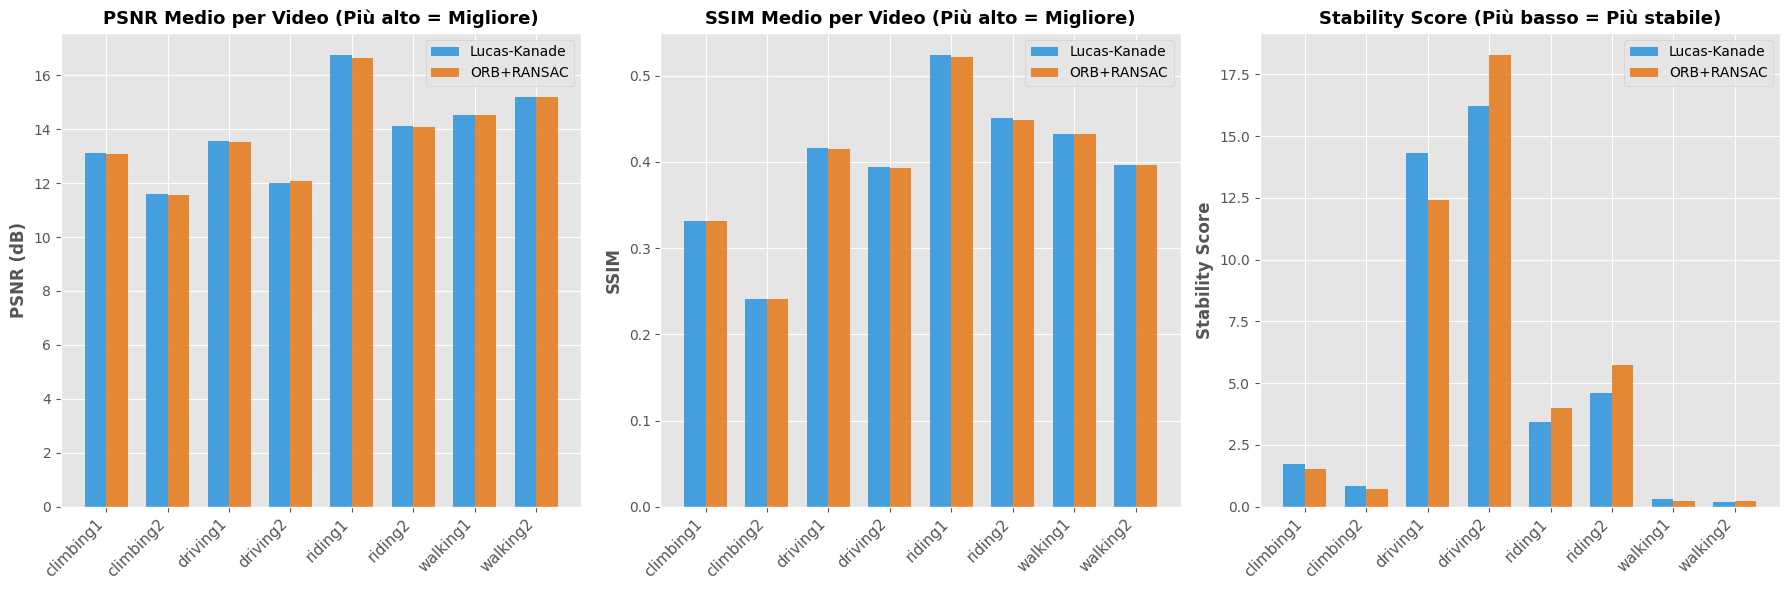

In [7]:
plt.style.use('ggplot')  

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

folders_list = list(all_results.keys())
x_pos = np.arange(len(folders_list))
width = 0.35

psnr_lk_vals = []
psnr_orb_vals = []
ssim_lk_vals = []
ssim_orb_vals = []
stab_lk_vals = []
stab_orb_vals = []

for folder in folders_list:
    metrics = all_results[folder]
    scores = all_scores[folder]
    
    psnr_lk_vals.append(np.mean(metrics['psnr_lk']) if len(metrics['psnr_lk']) > 0 else 0)
    psnr_orb_vals.append(np.mean(metrics['psnr_orb']) if len(metrics['psnr_orb']) > 0 else 0)
    ssim_lk_vals.append(np.mean(metrics['ssim_lk']) if len(metrics['ssim_lk']) > 0 else 0)
    ssim_orb_vals.append(np.mean(metrics['ssim_orb']) if len(metrics['ssim_orb']) > 0 else 0)
    stab_lk_vals.append(scores['lk']['total'])
    stab_orb_vals.append(scores['orb']['total'])

# PSNR comparison
axes[0].bar(x_pos - width/2, psnr_lk_vals, width, label='Lucas-Kanade', color='#3498db', alpha=0.9)
axes[0].bar(x_pos + width/2, psnr_orb_vals, width, label='ORB+RANSAC', color='#e67e22', alpha=0.9)
axes[0].set_ylabel('PSNR (dB)', fontweight='bold')
axes[0].set_title('PSNR Medio per Video (Più alto = Migliore)', fontsize=13, fontweight='bold')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(folders_list, rotation=45, ha='right', fontsize=11)
axes[0].legend()

# SSIM comparison
axes[1].bar(x_pos - width/2, ssim_lk_vals, width, label='Lucas-Kanade', color='#3498db', alpha=0.9)
axes[1].bar(x_pos + width/2, ssim_orb_vals, width, label='ORB+RANSAC', color='#e67e22', alpha=0.9)
axes[1].set_ylabel('SSIM', fontweight='bold')
axes[1].set_title('SSIM Medio per Video (Più alto = Migliore)', fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(folders_list, rotation=45, ha='right', fontsize=11)
axes[1].legend()

# Stability Score comparison (inverted: più basso = migliore)
axes[2].bar(x_pos - width/2, stab_lk_vals, width, label='Lucas-Kanade', color='#3498db', alpha=0.9)
axes[2].bar(x_pos + width/2, stab_orb_vals, width, label='ORB+RANSAC', color='#e67e22', alpha=0.9)
axes[2].set_ylabel('Stability Score', fontweight='bold')
axes[2].set_title('Stability Score (Più basso = Più stabile)', fontsize=13, fontweight='bold')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(folders_list, rotation=45, ha='right', fontsize=11)
axes[2].legend()

plt.tight_layout()
plt.show()


## Conclusioni Finali del Progetto

L'analisi quantitativa ci permette di confrontare oggettivamente i due metodi implementati, andando ben oltre la semplice percezione visiva.

### 1. I risultati dipendono dai dati
Guardando la tabella riassuntiva, emerge chiaramente che **non esiste un vincitore assoluto**. Entrambi i metodi eccellono in scenari diversi:

- **Quando vince Lucas-Kanade**: Se il video presenta movimenti della videocamera molto lisci, regolari e senza oggetti in rapido movimento in primo piano, Lucas-Kanade sfrutta l'Optical Flow continuo per ottenere una precisione *sub-pixel* eccellente. Inoltre, LK funziona bene anche quando ci sono poche "feature" evidenti, potendo seguire gradienti di intensità dove algoritmi come ORB faticano a trovare angoli nitidi (ad es. muri a tinta unita o forte *motion blur* in video "driving").
- **Quando vince ORB + RANSAC**: Trionfa in scenari complessi. Grazie ai descrittori ORB e al filtraggio **RANSAC**, l'algoritmo ignora completamente veicoli o persone in movimento nella scena (scartandoli come *outlier*). In video molto "shaky" (con forti sussulti), dove Lucas-Kanade perderebbe il tracciamento accumulando errore (*drift*), ORB ricalcola i punti a ogni frame mantenendo il video saldamente ancorato allo sfondo (*inlier*).

### 2. L'importanza delle Metriche Scelte
- **Stability Score**: Misura direttamente quanto "trema" il video; un valore basso conferma che le traslazioni tra i frame sono state abbattute con successo.
- **PSNR e SSIM**: Sono il "controllo qualità". Un algoritmo estremo potrebbe stabilizzare il video ma introdurre enormi bordi neri (crop) o distorsioni. PSNR e SSIM, confrontando l'output con il *groundtruth*, ci garantiscono che la fedeltà visiva dell'immagine sia stata preservata e che non siano stati inseriti artefatti fastidiosi.

### Sintesi
L'approccio **ORB+RANSAC** rappresenta un upgrade ingegneristico notevole per la sua *robustezza* a disturbi e occlusioni, mentre **Lucas-Kanade** si conferma imbattibile per *precisione* in scenari di movimento "pulito".